In [1]:
# environment: fewshot_eegpt
import random 
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Subset, DataLoader
import pytorch_lightning as pl
from functools import partial
import numpy as np
import random
import os 
import tqdm
from pytorch_lightning.callbacks import ModelCheckpoint, LearningRateMonitor
from pytorch_lightning import loggers as pl_loggers
import torch.nn.functional as F
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, f1_score
from models.transformer import (TransformerEncoder,
                                TransformerEncoderLayer)
from models.helpers import (ACTIVATION_DICT, NORM_DICT, WEIGHT_INIT_DICT,
                            get_clones)
from models.helpers import GenericMLP
from models.helpers import get_clones, WEIGHT_INIT_DICT, NORM_DICT, ACTIVATION_DICT
import Modules.LaBraM.modeling_finetune
import timm.models
from timm.models import create_model
import torch
from utils_EEGPT import temporal_interpolation
from utils_eval import get_metrics
from Modules.Transformers.pos_embed import create_1d_absolute_sin_cos_embedding
from Modules.models.EEGPT_mcae import EEGTransformer
from Modules.Network.utils import Conv1dWithConstraint, LinearWithConstraint
from vigilance_datasets import build_dataset, build_dataset_zeroshot, build_dataset_fewshot
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr

from collections import OrderedDict

from Modules.BIOT.biot import (
    BIOTClassifier,
)

import matplotlib.pyplot as plt

/home/lic45/anaconda3/envs/fewshot_eegpt/lib/python3.8/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/lic45/anaconda3/envs/fewshot_eegpt/lib/python3.8/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)


In [2]:
torch.set_float32_matmul_precision('medium' )
batch_size=32
nihecr_zeroshot_dataset = build_dataset_zeroshot("NIHECR_alphatheta_smallinterval_1024")
nihecr_zeroshot_loader  = DataLoader(nihecr_zeroshot_dataset,  batch_size=batch_size, shuffle=False, num_workers=8)

eegfmri_vu_train_dataset, eegfmri_vu_test_dataset = build_dataset_fewshot("eegfmri_vu_alphatheta_smallinterval_1024")
eegfmri_vu_train_loader  = DataLoader(eegfmri_vu_train_dataset,  batch_size=batch_size, shuffle=False, num_workers=8)
eegfmri_vu_test_loader  = DataLoader(eegfmri_vu_test_dataset,  batch_size=batch_size, shuffle=False, num_workers=8)

eegfmri_vu_pat_zeroshot_dataset = build_dataset_zeroshot("eegfmri_vu_pat_alphatheta_smallinterval_1024")
eegfmri_vu_pat_zeroshot_loader  = DataLoader(eegfmri_vu_pat_zeroshot_dataset,  batch_size=batch_size, shuffle=False, num_workers=8)

Initializing the Dataset:
Overall subjects:
dict_keys(['sub_0010', 'sub_0012', 'sub_0014', 'sub_0016', 'sub_0021', 'sub_0027', 'sub_0028', 'sub_0029', 'sub_0030', 'sub_0031', 'sub_0032'])
Successfully created the zero_shot dataset, with item names:
['sub_0010-mr_0009-ecr_echo1', 'sub_0010-mr_0015-ecr_echo1', 'sub_0012-mr_0012-ecr_echo1', 'sub_0012-mr_0018-ecr_echo1', 'sub_0014-mr_0012-ecr_echo1', 'sub_0014-mr_0018-ecr_echo1', 'sub_0016-mr_0006-ecr_echo1', 'sub_0016-mr_0015-ecr_echo1', 'sub_0021-mr_0012-ecr_echo1', 'sub_0027-mr_0009-ecr_echo1', 'sub_0028-mr_0012-ecr_echo1', 'sub_0029-mr_0009-ecr_echo1', 'sub_0029-mr_0012-ecr_echo1', 'sub_0030-mr_0009-ecr_echo1', 'sub_0031-mr_0015-ecr_echo1', 'sub_0032-mr_0009-ecr_echo1']
With zero_shot subjects:
{'sub_00': 16}
Reading /home/lic45/Documents/workspace/NIH/EEG30/sub_0010-mr_0009-ecr_echo1_EEG_pp.set_30.fdt


/home/lic45/Documents/GitHub/FewShotKDVigilance/00_SPIE_EEGPT/EEGPT-main/downstream/vigilance_datasets/NIHECR_alphatheta_smallinterval_1024.py:277: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  eeg_data = mne.io.read_raw_eeglab(eeg_scan_path)


Used Annotations descriptions: ['R', 'R128', 'Sync On', 'boundary']
Reading /home/lic45/Documents/workspace/NIH/EEG30/sub_0010-mr_0015-ecr_echo1_EEG_pp.set_30.fdt


/home/lic45/Documents/GitHub/FewShotKDVigilance/00_SPIE_EEGPT/EEGPT-main/downstream/vigilance_datasets/NIHECR_alphatheta_smallinterval_1024.py:277: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  eeg_data = mne.io.read_raw_eeglab(eeg_scan_path)


Used Annotations descriptions: ['R', 'R128', 'Sync On', 'boundary']
Reading /home/lic45/Documents/workspace/NIH/EEG30/sub_0012-mr_0012-ecr_echo1_EEG_pp.set_30.fdt


...

Used Annotations descriptions: ['R', 'R 21', 'R149', 'Sync On', 'TEND', 'TPEAK', 'TSTART', 'boundary']
Reading /home/lic45/Documents/workspace/eegfmri_vu/eegfmri_vu_uniform_26/vcon29/eeg/scan02/vcon29-scan02_eeg_pp.set_26.fdt


/home/lic45/Documents/GitHub/FewShotKDVigilance/00_SPIE_EEGPT/EEGPT-main/downstream/vigilance_datasets/eegfmri_vu_alphatheta_smallinterval_1024.py:393: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  eeg_data = mne.io.read_raw_eeglab(eeg_scan_path)
/home/lic45/Documents/GitHub/FewShotKDVigilance/00_SPIE_EEGPT/EEGPT-main/downstream/vigilance_datasets/eegfmri_vu_alphatheta_smallinterval_1024.py:393: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  eeg_data = mne.io.read_raw_eeglab(eeg_scan_path)


Used Annotations descriptions: ['R', 'R 21', 'R149', 'Sync On', 'boundary']
Reading /home/lic45/Documents/workspace/eegfmri_vu/eegfmri_vu_uniform_26/vcon32/eeg/scan01/vcon32-scan01_eeg_pp.set_26.fdt


/home/lic45/Documents/GitHub/FewShotKDVigilance/00_SPIE_EEGPT/EEGPT-main/downstream/vigilance_datasets/eegfmri_vu_alphatheta_smallinterval_1024.py:393: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  eeg_data = mne.io.read_raw_eeglab(eeg_scan_path)
/home/lic45/Documents/GitHub/FewShotKDVigilance/00_SPIE_EEGPT/EEGPT-main/downstream/vigilance_datasets/eegfmri_vu_alphatheta_smallinterval_1024.py:393: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  eeg_data = mne.io.read_raw_eeglab(eeg_scan_path)


Used Annotations descriptions: ['R', 'R 21', 'R149', 'Sync On', 'boundary']
self.eeg_data: (23, 299250, 26)
self.fmri_data: (23, 570, 1024)
self.physio_data: (23, 570, 5)
self.eeg_index_full_total: (23, 1193, 1)
self.eeg_index_linear_raw_total: (23, 570, 1)
self.eeg_index_linear_smoothed_total: (23, 570)
self.eeg_index_binary_total: (23, 570, 1)
self.alpha_theta_ratio_total: (23, 570)
self.windowed_fmri: (2622, 5, 1024)
self.windowed_eeg: (2622, 2625, 26)
self.windowed_physio: (2622, 5, 5)
self.windowed_eeg_index_linear_raw_total: (2622, 5, 1)
self.windowed_eeg_index_linear_smoothed_total: (2622, 5)
self.windowed_eeg_index_binary_total: (2622, 5, 1)
self.windowed_alpha_theta_ratio_total: (2622, 5)
self.windowed_vigilance_seg: (2622, 1)
Initializing the Dataset:
Overall subjects:
dict_keys(['vpat01', 'vpat02', 'vpat03', 'vpat04', 'vpat05'])
Successfully created the zero_shot dataset, with item names:
['vpat01-scan01', 'vpat01-scan02', 'vpat02-scan01', 'vpat03-scan01', 'vpat04-scan01', '

In [3]:
print(nihecr_zeroshot_dataset.windowed_fmri.shape)
print(eegfmri_vu_train_dataset.windowed_fmri.shape)
print(eegfmri_vu_test_dataset.windowed_fmri.shape)
print(eegfmri_vu_pat_zeroshot_dataset.windowed_fmri.shape)

(2208, 5, 1024)
(684, 5, 1024)
(2622, 5, 1024)
(912, 5, 1024)


In [4]:
global_folder_name = "EEGvigilance/stage1_labramBIOTEEGPT_kd_fewshot_transformer/"
folder_names = ["eegfmri_vu_alphatheta_smallinterval_1024_train/",
                "eegfmri_vu_alphatheta_smallinterval_1024_test/",
                "NIHECR_alphatheta_smallinterval_1024_zeroshot/",
                "eegfmri_vu_pat_alphatheta_smallinterval_1024/"]

In [5]:
def collect_data(global_folder_name, folder_name):
    data_path = global_folder_name + folder_name
    fmri_feats_path = data_path + "fmri_feats.pt"
    fmri_logits_path = data_path + "fmri_logits.pt"
    fmri_feats = torch.load(fmri_feats_path).numpy()
    fmri_logits = torch.load(fmri_logits_path).numpy()
    collected_data = {}
    collected_data["data_path"] = data_path
    collected_data["fmri_feats"] = fmri_feats
    collected_data["fmri_logits"] = fmri_logits
    if folder_name != "eegfmri_vu_pat_alphatheta_smallinterval_1024/":
        gts_path = data_path + "gts.pt"
        gts = torch.load(gts_path).numpy()
        collected_data["gts"] = gts
    print("data collected from " + data_path + "successful!")
    return collected_data

In [6]:
eegfmri_vu_alphatheta_smallinterval_1024_train_data = collect_data(global_folder_name, folder_names[0])
eegfmri_vu_alphatheta_smallinterval_1024_test_data = collect_data(global_folder_name, folder_names[1])
nihECR_alphatheta_smallinterval_1024_zeroshot_data = collect_data(global_folder_name, folder_names[2])
eegfmri_vu_pat_alphatheta_smallinterval_1024_data = collect_data(global_folder_name, folder_names[3])

data collected from EEGvigilance/stage1_labramBIOTEEGPT_kd_fewshot_transformer/eegfmri_vu_alphatheta_smallinterval_1024_train/successful!
data collected from EEGvigilance/stage1_labramBIOTEEGPT_kd_fewshot_transformer/eegfmri_vu_alphatheta_smallinterval_1024_test/successful!
data collected from EEGvigilance/stage1_labramBIOTEEGPT_kd_fewshot_transformer/NIHECR_alphatheta_smallinterval_1024_zeroshot/successful!
data collected from EEGvigilance/stage1_labramBIOTEEGPT_kd_fewshot_transformer/eegfmri_vu_pat_alphatheta_smallinterval_1024/successful!


/tmp/ipykernel_1574621/173927014.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  fmri_feats = torch.load(fmri_feats_path).numpy()
/tmp/ipykernel_1574621/173927014.py:6: 

In [7]:
def plot_results(collected_data, dataset):
    scan_len = len(dataset.scan_names)
    ratio = collected_data["fmri_logits"].shape[0] // scan_len
    save_folder = collected_data["data_path"] + "/plots/"
    os.makedirs(save_folder, exist_ok=True)
    pred = np.argmax(collected_data["fmri_logits"], axis=1)
    for idx in range(scan_len):
        pred_chunk = pred[idx*ratio:(idx+1)*ratio]
        gt_chunk = collected_data["gts"][idx*ratio:(idx+1)*ratio]
        scan_name = dataset.scan_names[idx]
        eeg_index_binary_total = dataset.eeg_index_binary_total[idx]
        eeg_index_linear_smoothed_total = dataset.eeg_index_linear_smoothed_total[idx]
        full_pred = []
        full_gt = []
        for i in range(ratio):
            for _ in range(5):
                full_pred.append(pred_chunk[i])
                full_gt.append(gt_chunk[i])
        x = np.arange(len(full_pred))
        plt.figure(figsize=(20, 6))
        plt.plot(x, full_gt, label='5-frame-wise ground truth', linewidth=5, color='orange')
        plt.plot(x, eeg_index_linear_smoothed_total, label='smoothed VIGALL labels ranging 2 to 6', linewidth=3, color='green')
        plt.plot(x, full_pred, label='predictions', linewidth=4, color='blue')
        plt.xlabel('time', fontsize=25)
        plt.ylabel('VIGALL labels', fontsize=25)
        plt.xticks(fontsize=16)  # Set x-axis tick label font size
        plt.yticks(fontsize=16)
        plt.ylim(-0.25, 6.25) 
        plt.legend(fontsize=20, loc='upper right', frameon=True)
        plt.grid(True)
        # plt.show()
        save_path = os.path.join(save_folder, f"{scan_name}_predictions.png")
        plt.savefig(save_path, dpi=300, bbox_inches='tight')  
        plt.close()  
        print(f"Plot saved at: {save_path}")
        

In [7]:
plot_results(eegfmri_vu_alphatheta_smallinterval_1024_train_data, eegfmri_vu_train_dataset)
plot_results(eegfmri_vu_alphatheta_smallinterval_1024_test_data, eegfmri_vu_test_dataset)
plot_results(nihECR_alphatheta_smallinterval_1024_zeroshot_data, nihecr_zeroshot_dataset)
# plot_results(eegfmri_vu_pat_alphatheta_smallinterval_1024_data, eegfmri_vu_pat_zeroshot_dataset)

Plot saved at: EEGvigilance/stage1_labramBIOTEEGPT_kd_fewshot_transformer/eegfmri_vu_alphatheta_smallinterval_1024_train//plots/vcon02-scan01_predictions.png
Plot saved at: EEGvigilance/stage1_labramBIOTEEGPT_kd_fewshot_transformer/eegfmri_vu_alphatheta_smallinterval_1024_train//plots/vcon09-scan01_predictions.png
Plot saved at: EEGvigilance/stage1_labramBIOTEEGPT_kd_fewshot_transformer/eegfmri_vu_alphatheta_smallinterval_1024_train//plots/vcon09-scan02_predictions.png
Plot saved at: EEGvigilance/stage1_labramBIOTEEGPT_kd_fewshot_transformer/eegfmri_vu_alphatheta_smallinterval_1024_train//plots/vcon17-scan01_predictions.png
Plot saved at: EEGvigilance/stage1_labramBIOTEEGPT_kd_fewshot_transformer/eegfmri_vu_alphatheta_smallinterval_1024_train//plots/vcon27-scan02_predictions.png
Plot saved at: EEGvigilance/stage1_labramBIOTEEGPT_kd_fewshot_transformer/eegfmri_vu_alphatheta_smallinterval_1024_train//plots/vcon30-scan01_predictions.png
Plot saved at: EEGvigilance/stage1_labramBIOTEEGPT_k

In [ ]:
import matplotlib.pyplot as plt
from umap import UMAP
import numpy as np

def plot_umap_labeled_vs_unlabeled(labeled_data, unlabeled_data, labeled_tag="Labeled", unlabeled_tag="Unlabeled", label_prefix="Class"):
    labeled_feats = labeled_data["fmri_feats"]
    labeled_labels = labeled_data["gts"].reshape(-1)
    unlabeled_feats = unlabeled_data["fmri_feats"]
    unlabeled_labels = np.array([-1] * unlabeled_feats.shape[0])  # placeholder

    # Concatenate features and labels
    all_feats = np.concatenate([labeled_feats, unlabeled_feats], axis=0)
    all_labels = np.concatenate([labeled_labels, unlabeled_labels], axis=0)

    # UMAP embedding
    reducer = UMAP(n_neighbors=15, min_dist=0.1, metric="cosine", random_state=42)
    embedding = reducer.fit_transform(all_feats)

    # Masks
    labeled_mask = all_labels != -1
    unlabeled_mask = all_labels == -1

    # Plot
    cmap = plt.get_cmap("tab10")
    unique_classes = np.unique(labeled_labels)

    plt.figure(figsize=(10, 7))

    # Plot each labeled class separately
    classname = ["drowsy", "alert"]
    for class_id in unique_classes:
        print(f"class_id: {class_id}")
        print(f"classname[class_id]: {classname[class_id]}")
        class_mask = (labeled_labels == class_id)
        emb = embedding[labeled_mask][class_mask]
        plt.scatter(
            emb[:, 0], emb[:, 1],
            c=[cmap(class_id)],
            s=15,
            label=f"{labeled_tag}: {label_prefix} {classname[class_id]}",
            alpha=0.7
        )

    # Plot unlabeled
    plt.scatter(
        embedding[unlabeled_mask, 0], embedding[unlabeled_mask, 1],
        c="gray", s=15, label=f"{unlabeled_tag} (unlabeled)", alpha=0.5, marker="x"
    )

    plt.xlabel("UMAP dim1", fontsize=20)
    plt.ylabel("UMAP dim2", fontsize=20)
    plt.legend(fontsize=20, loc='upper right')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [9]:
print(eegfmri_vu_alphatheta_smallinterval_1024_train_data["fmri_feats"].shape)
print(eegfmri_vu_alphatheta_smallinterval_1024_test_data["fmri_feats"].shape)
print(nihECR_alphatheta_smallinterval_1024_zeroshot_data["fmri_feats"].shape)
print(eegfmri_vu_pat_alphatheta_smallinterval_1024_data["fmri_feats"].shape)

(684, 2560)
(2622, 2560)
(2208, 2560)
(912, 2560)


/home/lic45/anaconda3/envs/fewshot_eegpt/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


class_id: 0
classname[class_id]: drowsy
class_id: 1
classname[class_id]: alert


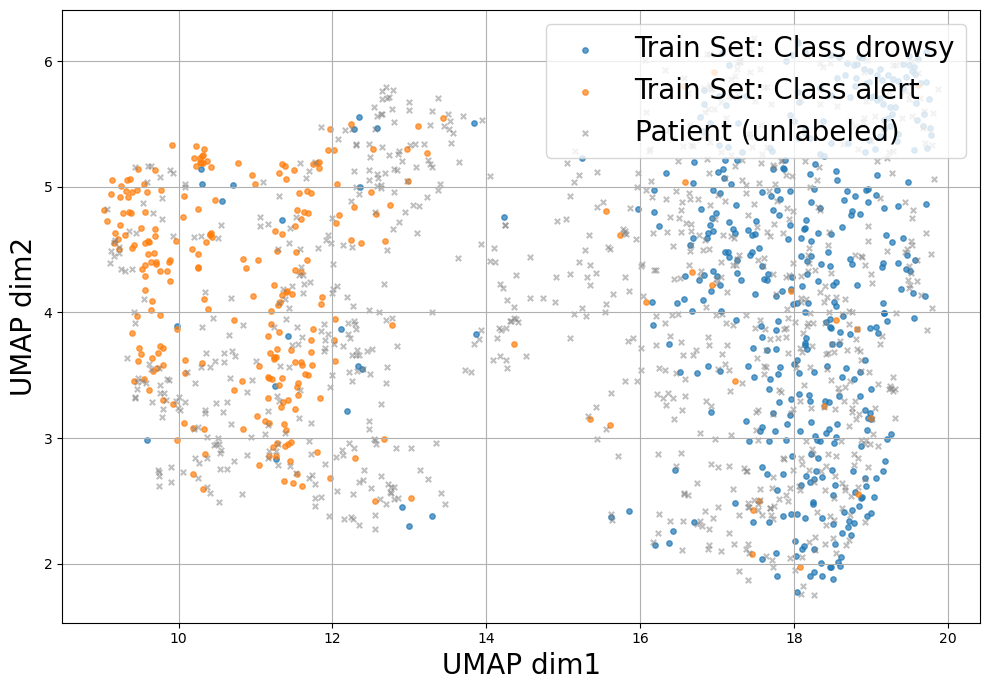

In [10]:
plot_umap_labeled_vs_unlabeled(
    eegfmri_vu_alphatheta_smallinterval_1024_train_data,
    eegfmri_vu_pat_alphatheta_smallinterval_1024_data,
    labeled_tag="Train Set",
    unlabeled_tag="Patient"
)

/home/lic45/anaconda3/envs/fewshot_eegpt/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


class_id: 0
classname[class_id]: drowsy
class_id: 1
classname[class_id]: alert


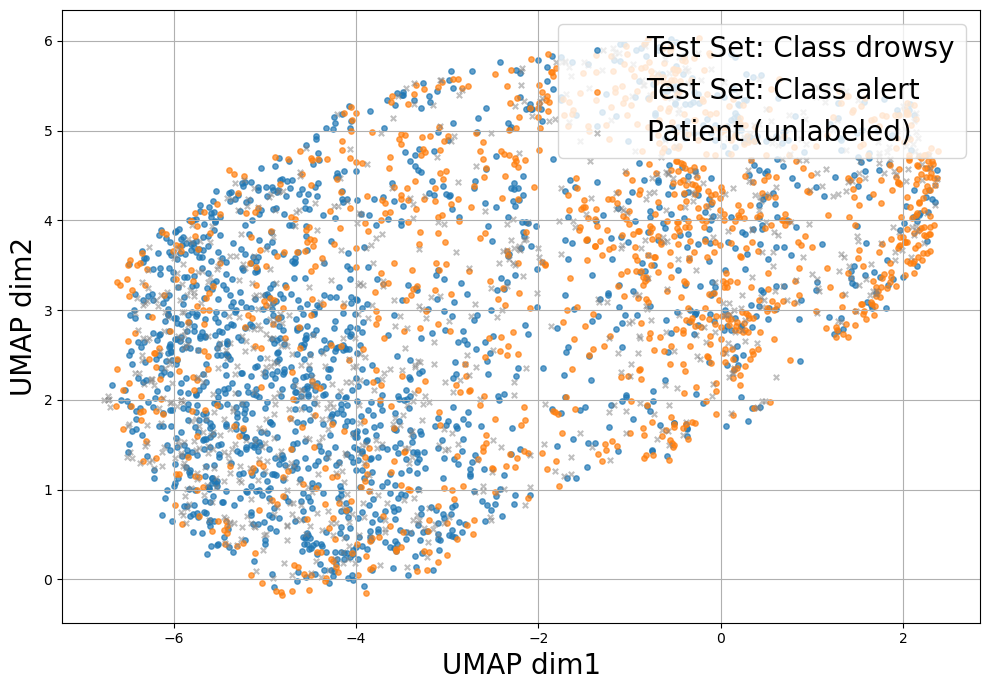

In [11]:
plot_umap_labeled_vs_unlabeled(
    eegfmri_vu_alphatheta_smallinterval_1024_test_data,
    eegfmri_vu_pat_alphatheta_smallinterval_1024_data,
    labeled_tag="Test Set",
    unlabeled_tag="Patient"
)

/home/lic45/anaconda3/envs/fewshot_eegpt/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


class_id: 0
classname[class_id]: drowsy
class_id: 1
classname[class_id]: alert


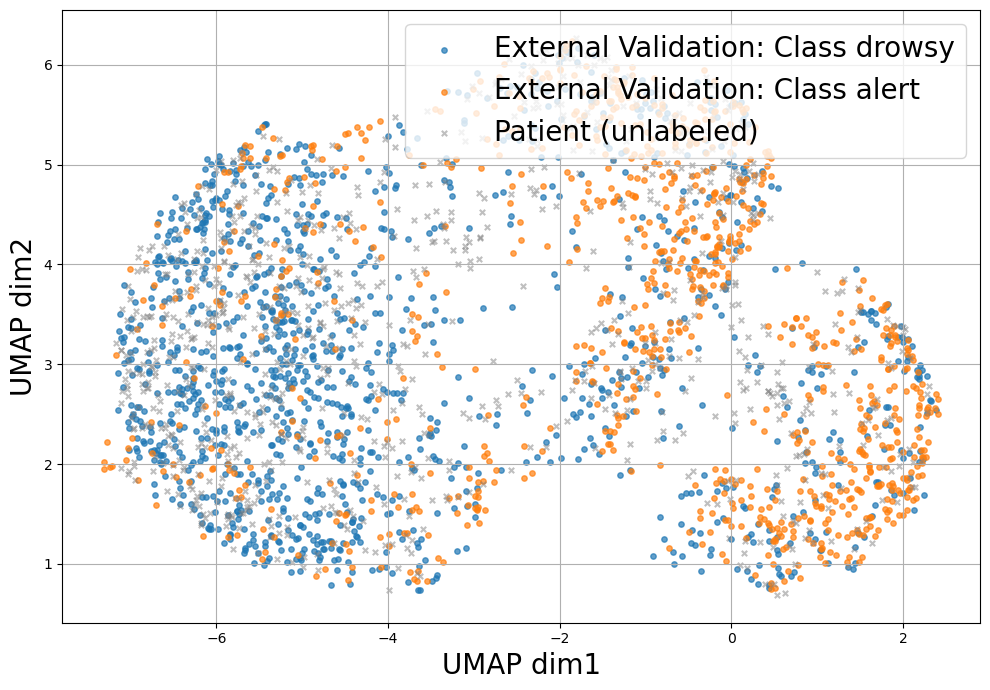

In [12]:
plot_umap_labeled_vs_unlabeled(
    nihECR_alphatheta_smallinterval_1024_zeroshot_data,
    eegfmri_vu_pat_alphatheta_smallinterval_1024_data,
    labeled_tag="External Validation",
    unlabeled_tag="Patient"
)

In [ ]:
import matplotlib.pyplot as plt
from umap import UMAP
import numpy as np

def plot_umap_labeled_vs_unlabeled_withoutlegend(labeled_data, unlabeled_data, labeled_tag="Labeled", unlabeled_tag="Unlabeled", label_prefix="Class"):
    labeled_feats = labeled_data["fmri_feats"]
    labeled_labels = labeled_data["gts"].reshape(-1)

    unlabeled_feats = unlabeled_data["fmri_feats"]
    unlabeled_labels = np.array([-1] * unlabeled_feats.shape[0])  # placeholder

    # Concatenate features and labels
    all_feats = np.concatenate([labeled_feats, unlabeled_feats], axis=0)
    all_labels = np.concatenate([labeled_labels, unlabeled_labels], axis=0)

    # UMAP embedding
    reducer = UMAP(n_neighbors=15, min_dist=0.1, metric="cosine", random_state=42)
    embedding = reducer.fit_transform(all_feats)

    # Masks
    labeled_mask = all_labels != -1
    unlabeled_mask = all_labels == -1

    # Plot
    cmap = plt.get_cmap("tab10")
    unique_classes = np.unique(labeled_labels)

    plt.figure(figsize=(10, 7))

    # Plot each labeled class separately
    classname = ["drowsy", "alert"]
    for class_id in unique_classes:
        print(f"class_id: {class_id}")
        print(f"classname[class_id]: {classname[class_id]}")
        class_mask = (labeled_labels == class_id)
        emb = embedding[labeled_mask][class_mask]
        plt.scatter(
            emb[:, 0], emb[:, 1],
            c=[cmap(class_id)],
            s=15,
            label=f"{labeled_tag}: {label_prefix} {classname[class_id]}",
            alpha=0.7
        )
        rgba = cmap(class_id)  # RGBA tuple
        hex_color = plt.matplotlib.colors.to_hex(rgba)
        print(f"color: {hex_color} for class name: {classname[class_id]}")

    # Plot unlabeled
    plt.scatter(
        embedding[unlabeled_mask, 0], embedding[unlabeled_mask, 1],
        c="gray", s=15, label=f"{unlabeled_tag} (unlabeled)", alpha=0.5, marker="x"
    )

    plt.xlabel("UMAP dim1", fontsize=20)
    plt.ylabel("UMAP dim2", fontsize=20)
    # plt.legend(fontsize=20, loc='upper right')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

/home/lic45/anaconda3/envs/fewshot_eegpt/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


class_id: 0
classname[class_id]: drowsy
color: #1f77b4 for class name: drowsy
class_id: 1
classname[class_id]: alert
color: #ff7f0e for class name: alert


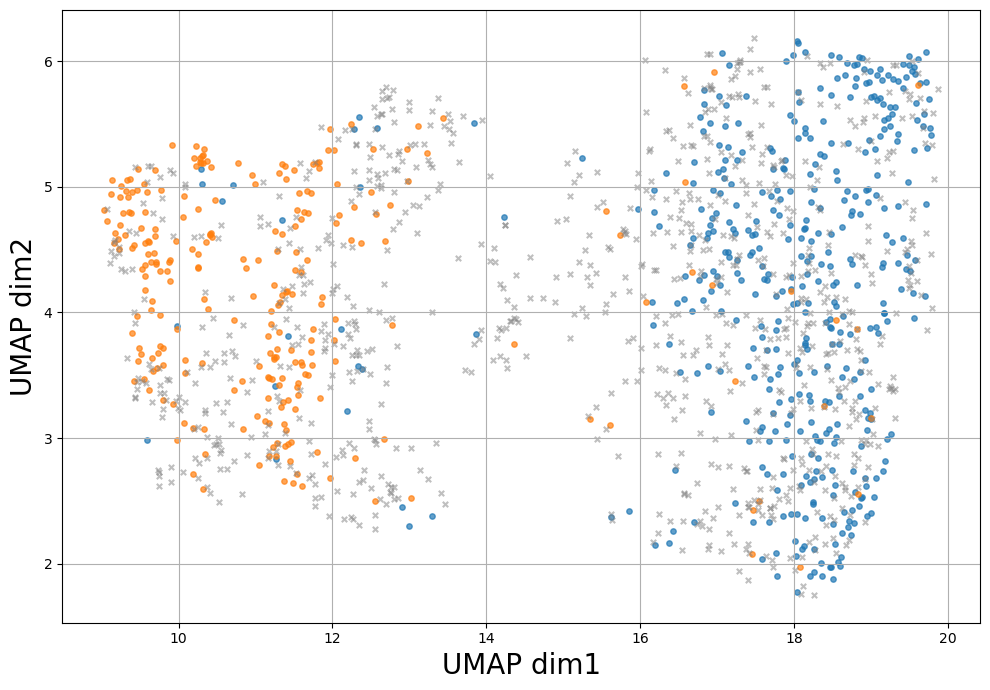

In [10]:
plot_umap_labeled_vs_unlabeled_withoutlegend(
    eegfmri_vu_alphatheta_smallinterval_1024_train_data,
    eegfmri_vu_pat_alphatheta_smallinterval_1024_data,
    labeled_tag="Train Set",
    unlabeled_tag="Patient"
)

/home/lic45/anaconda3/envs/fewshot_eegpt/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


class_id: 0
classname[class_id]: drowsy
color: #1f77b4 for class name: drowsy
class_id: 1
classname[class_id]: alert
color: #ff7f0e for class name: alert


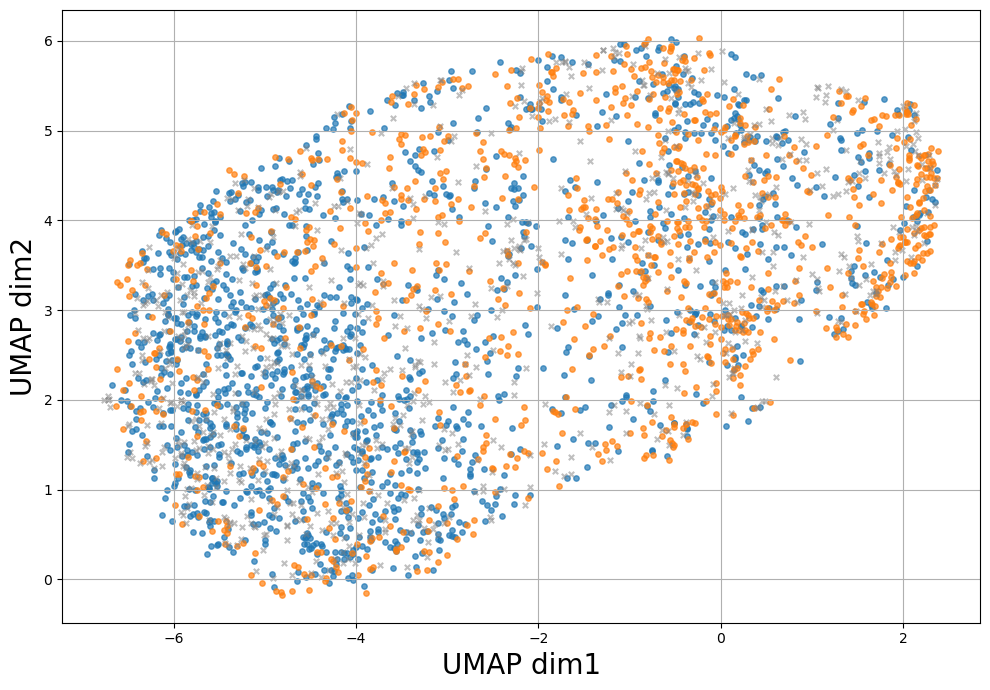

In [11]:
plot_umap_labeled_vs_unlabeled_withoutlegend(
    eegfmri_vu_alphatheta_smallinterval_1024_test_data,
    eegfmri_vu_pat_alphatheta_smallinterval_1024_data,
    labeled_tag="Test Set",
    unlabeled_tag="Patient"
)

/home/lic45/anaconda3/envs/fewshot_eegpt/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


class_id: 0
classname[class_id]: drowsy
color: #1f77b4 for class name: drowsy
class_id: 1
classname[class_id]: alert
color: #ff7f0e for class name: alert


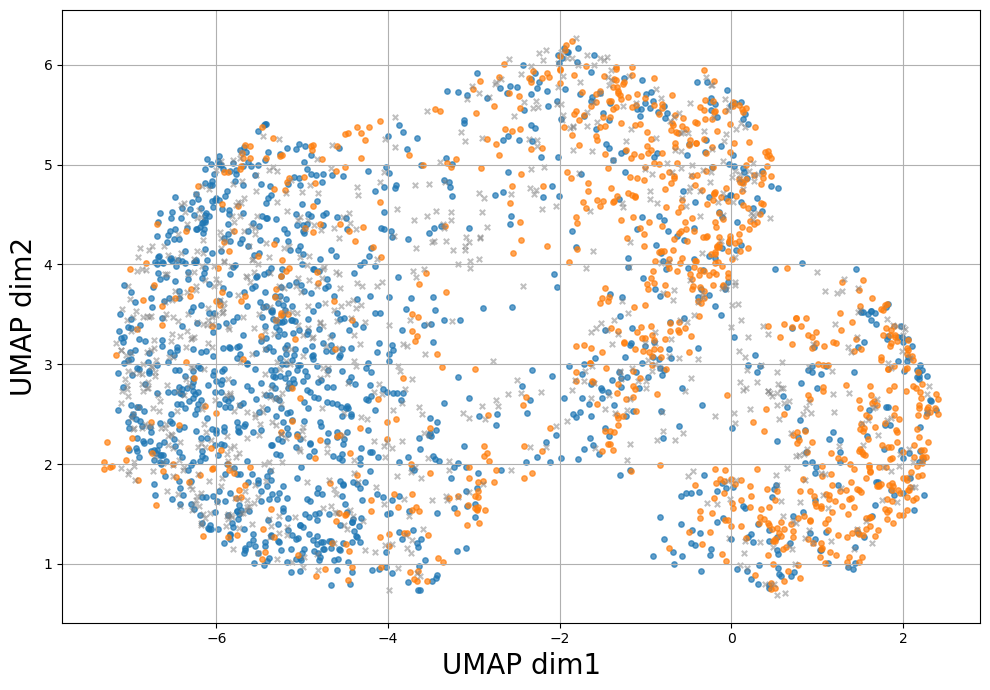

In [12]:
plot_umap_labeled_vs_unlabeled_withoutlegend(
    nihECR_alphatheta_smallinterval_1024_zeroshot_data,
    eegfmri_vu_pat_alphatheta_smallinterval_1024_data,
    labeled_tag="External Validation",
    unlabeled_tag="Patient"
)